## move data from drive to colab


In [ ]:
cd /content/drive/MyDrive/cv_22641171_NgoTruongDinh/lab_bo_sung_10 03 2026

/content/drive/MyDrive/cv_22641171_NgoTruongDinh/lab_bo_sung_10 03 2026


In [ ]:
cp -r '/content/drive/MyDrive/cv_22641171_NgoTruongDinh/lab_bo_sung_10 03 2026/new_Data/Covid19-Pneumonia-Normal Chest X-Ray Images Dataset.zip' /content

# data process

In [ ]:
import os

root = "/content/dataset"
valid_exts = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")

total = 0

for cls in os.listdir(root):
    cls_path = os.path.join(root, cls)
    if os.path.isdir(cls_path):
        n = sum(
            1 for f in os.listdir(cls_path)
            if f.lower().endswith(valid_exts)
        )
        print(f"{cls}: {n}")
        total += n

print("Tổng:", total)

PNEUMONIA: 1800
NORMAL: 1802
COVID: 1626
Tổng: 5228


In [ ]:
import os

import process_data

SRC_TRAIN = "/content/dataset"

OUT_ROOT = "/content/drive/MyDrive/cv_22641171_NgoTruongDinh/lab_bo_sung_10 03 2026/new_Data/new_dataset_processed"




train_classes = process_data.preprocess_split_mp(SRC_TRAIN,OUT_ROOT, max_workers=8)

print("Classes:", train_classes)

Preprocess dataset (workers=8):   0%|          | 0/5228 [00:00<?, ?it/s]

Done dataset: 5228/5228 files ok. Saved to: /content/drive/MyDrive/cv_22641171_NgoTruongDinh/lab_bo_sung_10 03 2026/new_Data/new_dataset_processed
Classes: ['COVID', 'NORMAL', 'PNEUMONIA']


In [ ]:
cp -r '/content/drive/MyDrive/cv_22641171_NgoTruongDinh/lab_bo_sung_10 03 2026/new_Data/new_dataset_processed' /content/data_processed

In [ ]:
import os

root = "/content/data_processed"
valid_exts = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")

total = 0

for cls in os.listdir(root):
    cls_path = os.path.join(root, cls)
    if os.path.isdir(cls_path):
        n = sum(
            1 for f in os.listdir(cls_path)
            if f.lower().endswith(valid_exts)
        )
        print(f"{cls}: {n}")
        total += n

print("Tổng:", total)

NORMAL: 1802
PNEUMONIA: 1800
COVID: 1626
Tổng: 5228


# ablation K-value

In [ ]:
!cp -r '/content/drive/MyDrive/cv_22641171_NgoTruongDinh/lab_bo_sung_10 03 2026/new_Data/new_dataset_processed' /content/data_processed

In [ ]:
import os
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor
import multiprocessing as mp

import numpy as np
from PIL import Image
from torchvision.datasets import ImageFolder
from tqdm.auto import tqdm

import encryption

SRC_ROOT = "/content/data_processed/new_dataset_processed"
OUT_ROOT = "/content/new_dataset_encrypted_ablationK/k_1"

IMG_SIZE = 224
SAVE_FMT = "PNG"
K = 1
BLOCK_XOR = 4
BLOCK_SHUFFLE = 16
SEED = 2024


def build_tasks(src_dir, out_dir):
    src_dir = str(src_dir)
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    ds = ImageFolder(src_dir)
    classes = ds.classes

    tasks = []
    ext = ".jpg" if SAVE_FMT.upper() == "JPEG" else ".png"

    for path, label in ds.samples:
        cls = classes[label]
        stem = Path(path).stem
        dst = out_dir / cls / f"{stem}{ext}"
        tasks.append((path, str(dst)))

    return tasks, classes, ds.class_to_idx


def preload_images(tasks):
    """
    Load toàn bộ ảnh vào RAM trước để giảm bottleneck I/O.
    Trả về list[(img_array, dst_path)].
    """
    loaded = []

    for src_path, dst_path in tqdm(tasks, desc="Preloading to RAM"):
        dst_path = Path(dst_path)

        # nếu file đã tồn tại thì bỏ qua luôn
        if dst_path.exists():
            loaded.append((None, str(dst_path)))
            continue

        try:
            with Image.open(src_path) as im:
                im = im.convert("RGB")
                if im.size != (IMG_SIZE, IMG_SIZE):
                    im = im.resize((IMG_SIZE, IMG_SIZE), resample=Image.BILINEAR)
                img = np.array(im, dtype=np.uint8)  # HWC uint8

            loaded.append((img, str(dst_path)))
        except Exception:
            loaded.append((None, str(dst_path)))

    return loaded


def _encrypt_and_save(item):
    """
    Worker process:
    - nhận img đã nằm sẵn trong RAM
    - encrypt
    - save
    """
    img, dst_path = item
    try:
        if img is None:
            return False

        dst_path = Path(dst_path)
        dst_path.parent.mkdir(parents=True, exist_ok=True)

        enc = encryption.advanced_learnable_encrypt(
            img,
            k=K,
            block_xor=BLOCK_XOR,
            block_shuffle=BLOCK_SHUFFLE,
            seed=SEED
        )

        Image.fromarray(enc).save(dst_path, format=SAVE_FMT, optimize=False)
        return True
    except Exception:
        return False


def encrypt_split_mp_preload(src_dir, out_dir, max_workers=None, chunksize=64):
    tasks, classes, class_to_idx = build_tasks(src_dir, out_dir)

    # preload toàn bộ vào RAM
    loaded = preload_images(tasks)

    # chỉ giữ các ảnh chưa tồn tại + load OK
    loaded = [(img, dst) for img, dst in loaded if img is not None and not Path(dst).exists()]

    total = len(loaded)
    if total == 0:
        print(f"Done {Path(src_dir).name}: nothing to process -> {out_dir}")
        print("class_to_idx:", class_to_idx)
        return classes

    if max_workers is None:
        max_workers = os.cpu_count() or 4

    with ProcessPoolExecutor(max_workers=max_workers, mp_context=mp.get_context("fork")) as ex:
        results = list(
            tqdm(
                ex.map(_encrypt_and_save, loaded, chunksize=chunksize),
                total=total,
                desc=f"Encrypt {Path(src_dir).name} (workers={max_workers})"
            )
        )

    ok = sum(bool(x) for x in results)

    print(f"Done {Path(src_dir).name}: {ok}/{total} ok -> {out_dir}")
    print("class_to_idx:", class_to_idx)
    return classes


if __name__ == "__main__":
    workers = os.cpu_count() or 4

    train_classes = encrypt_split_mp_preload(
        SRC_ROOT,
        OUT_ROOT,
        max_workers=workers,
        chunksize=64
    )

    print("Classes:", train_classes)

Preloading to RAM:   0%|          | 0/5228 [00:00<?, ?it/s]

Encrypt new_dataset_processed (workers=12):   0%|          | 0/5228 [00:00<?, ?it/s]

Done new_dataset_processed: 5228/5228 ok -> /content/new_dataset_encrypted_ablationK/k_1
class_to_idx: {'COVID': 0, 'NORMAL': 1, 'PNEUMONIA': 2}
Classes: ['COVID', 'NORMAL', 'PNEUMONIA']


In [ ]:
from pathlib import Path

import numpy as np
from PIL import Image
from torchvision.datasets import ImageFolder

import encryption


# ============================================================
# CONFIG
# ============================================================

SRC_ROOT = Path("/content/data_processed/new_dataset_processed")

# Giữ nguyên root đang dùng trong code đánh giá
ABLATION_ROOT = Path("/content/new_dataset_encrypted_ablationK")

# Ảnh gốc và ảnh mã hóa được tách riêng
ORIGINAL_ROOT = ABLATION_ROOT / "original"
ENCRYPTED_ROOT = ABLATION_ROOT / "k_8"

TARGET_CLASS = "NORMAL"

IMG_SIZE = 224
SAVE_FMT = "PNG"

K = 8
BLOCK_XOR = 4
BLOCK_SHUFFLE = 16
SEED = 2024

# True: ghi đè file đã tồn tại
OVERWRITE = True


# ============================================================
# LOAD ONE IMAGE
# ============================================================

def select_one_image(
    src_root: Path,
    target_class: str = "NORMAL"
):
    """
    Chọn đúng một ảnh thuộc target_class.

    Trả về:
    - src_path: đường dẫn ảnh nguồn
    - rel_path: đường dẫn tương đối, ví dụ NORMAL/image.png
    - label
    - class_to_idx
    """
    dataset = ImageFolder(str(src_root))

    if target_class not in dataset.class_to_idx:
        raise ValueError(
            f"Không tìm thấy lớp '{target_class}'. "
            f"Các lớp hiện có: {dataset.classes}"
        )

    target_label = dataset.class_to_idx[target_class]

    for src_path, label in dataset.samples:
        if label != target_label:
            continue

        src_path = Path(src_path)
        rel_path = src_path.relative_to(src_root)

        print("Selected image:", src_path)
        print("Relative path:", rel_path)
        print("Class:", target_class)
        print("Label:", label)
        print("class_to_idx:", dataset.class_to_idx)

        return {
            "src_path": src_path,
            "rel_path": rel_path,
            "label": int(label),
            "class_name": target_class,
            "class_to_idx": dataset.class_to_idx,
        }

    raise RuntimeError(
        f"Không tìm thấy ảnh nào thuộc lớp '{target_class}'."
    )


# ============================================================
# IMAGE UTILS
# ============================================================

def load_rgb_image(
    image_path: Path,
    image_size: int = 224
) -> np.ndarray:
    """
    Đọc ảnh RGB và trả về numpy uint8, shape HWC.
    """
    with Image.open(image_path) as image:
        image = image.convert("RGB")

        if image.size != (image_size, image_size):
            image = image.resize(
                (image_size, image_size),
                resample=Image.BILINEAR
            )

        return np.asarray(image, dtype=np.uint8)


def build_output_path(
    output_root: Path,
    rel_path: Path
) -> Path:
    """
    Giữ nguyên thư mục lớp và tên ảnh,
    chỉ đổi phần mở rộng theo SAVE_FMT.
    """
    extension = (
        ".jpg"
        if SAVE_FMT.upper() in {"JPG", "JPEG"}
        else ".png"
    )

    output_path = output_root / rel_path
    return output_path.with_suffix(extension)


def save_image(
    image: np.ndarray,
    output_path: Path
):
    output_path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    Image.fromarray(
        image.astype(np.uint8)
    ).save(
        output_path,
        format=SAVE_FMT,
        optimize=False
    )


# ============================================================
# SAVE ORIGINAL + ENCRYPT ONE IMAGE
# ============================================================

def encrypt_one_image():
    sample = select_one_image(
        src_root=SRC_ROOT,
        target_class=TARGET_CLASS
    )

    src_path = sample["src_path"]
    rel_path = sample["rel_path"]

    original_output_path = build_output_path(
        ORIGINAL_ROOT,
        rel_path
    )

    encrypted_output_path = build_output_path(
        ENCRYPTED_ROOT,
        rel_path
    )

    if not OVERWRITE:
        if (
            original_output_path.exists()
            and encrypted_output_path.exists()
        ):
            print("Các file đã tồn tại, không xử lý lại.")
            print("Original:", original_output_path)
            print("Encrypted:", encrypted_output_path)
            return sample

    # Đọc đúng một lần
    original_image = load_rgb_image(
        src_path,
        image_size=IMG_SIZE
    )

    # Lưu ảnh gốc đã resize
    save_image(
        original_image,
        original_output_path
    )

    # Mã hóa cùng ảnh đó
    encrypted_image = encryption.advanced_learnable_encrypt(
        original_image,
        k=K,
        block_xor=BLOCK_XOR,
        block_shuffle=BLOCK_SHUFFLE,
        seed=SEED
    )

    encrypted_image = np.asarray(
        encrypted_image,
        dtype=np.uint8
    )

    if encrypted_image.shape != original_image.shape:
        raise ValueError(
            "Kích thước ảnh mã hóa không khớp ảnh gốc: "
            f"{encrypted_image.shape} != {original_image.shape}"
        )

    save_image(
        encrypted_image,
        encrypted_output_path
    )

    print("\nHoàn thành.")
    print("Original :", original_output_path)
    print("Encrypted:", encrypted_output_path)
    print("Shape    :", original_image.shape)
    print("k        :", K)

    return {
        **sample,
        "original_path": str(original_output_path),
        "encrypted_path": str(encrypted_output_path),
    }


result = encrypt_one_image()

Selected image: /content/data_processed/new_dataset_processed/NORMAL/001626.png
Relative path: NORMAL/001626.png
Class: NORMAL
Label: 1
class_to_idx: {'COVID': 0, 'NORMAL': 1, 'PNEUMONIA': 2}

Hoàn thành.
Original : /content/new_dataset_encrypted_ablationK/original/NORMAL/001626.png
Encrypted: /content/new_dataset_encrypted_ablationK/k_8/NORMAL/001626.png
Shape    : (224, 224, 3)
k        : 8


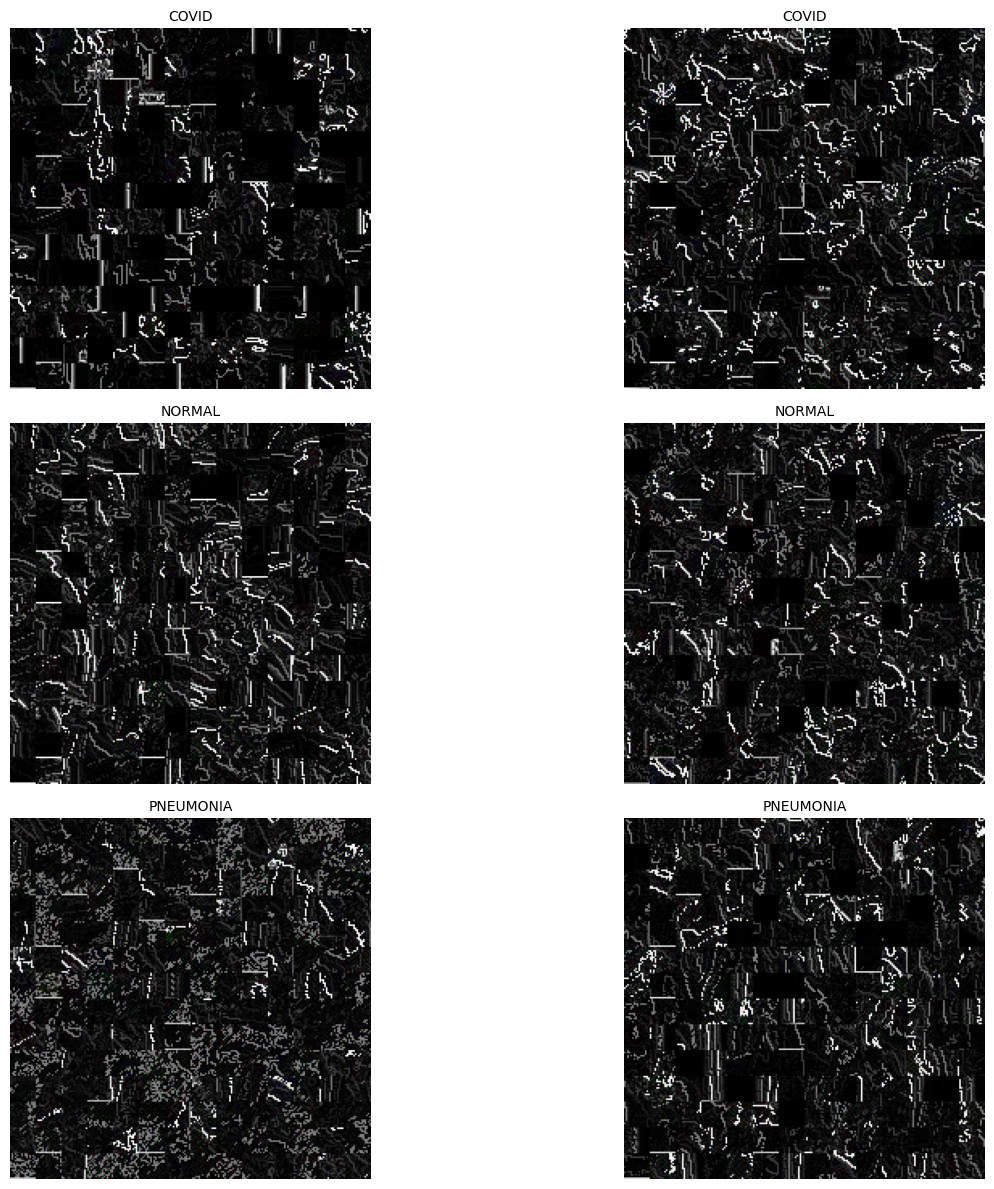

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

root = "/content/new_dataset_encrypted/k_8"
valid_exts = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")

classes = sorted([
    cls for cls in os.listdir(root)
    if os.path.isdir(os.path.join(root, cls))
])

num_rows = len(classes)
num_cols = 2

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 4 * num_rows))

if num_rows == 1:
    axes = [axes]

for i, cls in enumerate(classes):
    cls_path = os.path.join(root, cls)

    imgs = [
        os.path.join(cls_path, f)
        for f in os.listdir(cls_path)
        if f.lower().endswith(valid_exts)
    ]

    chosen = random.sample(imgs, min(num_cols, len(imgs)))

    for j in range(num_cols):
        ax = axes[i][j] if num_rows > 1 else axes[j]

        if j < len(chosen):
            img = Image.open(chosen[j]).convert("RGB")
            ax.imshow(img)
            ax.set_title(f"{cls}", fontsize=10)
        else:
            ax.imshow([[255]])
            ax.set_title(f"{cls}\n(empty)", fontsize=9)

        ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import torch
from torch.utils.data import DataLoader, Subset
import numpy as np
from tqdm.auto import tqdm

def compute_mean_std(dataset, batch_size=64, num_workers=4, max_samples=2000, seed=42):

    n = len(dataset)
    if max_samples is not None and max_samples < n:
        rng = np.random.default_rng(seed)
        idx = rng.choice(n, size=max_samples, replace=False)
        dataset = Subset(dataset, idx.tolist())

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                        num_workers=num_workers, pin_memory=True)

    channel_sum = torch.zeros(3)
    channel_sumsq = torch.zeros(3)
    pixel_count = 0

    for x, _ in tqdm(loader, desc="Compute mean/std"):
        # x: [B,3,H,W] in [0,1]
        b, c, h, w = x.shape
        x = x.float()

        channel_sum += x.sum(dim=[0,2,3])
        channel_sumsq += (x ** 2).sum(dim=[0,2,3])
        pixel_count += b * h * w

    mean = channel_sum / pixel_count
    var = channel_sumsq / pixel_count - mean**2
    std = torch.sqrt(var.clamp_min(1e-12))

    return mean.tolist(), std.tolist()


## k = 1

In [ ]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import Subset
from sklearn.model_selection import train_test_split
import numpy as np

ENC_ROOT = "/content/new_dataset_encrypted/k_1"

BATCH_SIZE = 128
NUM_WORKERS = 12
SEED = 42


# Load toàn bộ dataset, không cần folder train/test
full_ds = ImageFolder(ENC_ROOT)

targets = np.array(full_ds.targets)
indices = np.arange(len(full_ds))


# Split train / temp
train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.3,
    stratify=targets,
    random_state=SEED
)

# Split temp thành val / test
temp_targets = targets[temp_idx]

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    stratify=temp_targets,
    random_state=SEED
)


print("Train:", len(train_idx))
print("Val:", len(val_idx))
print("Test:", len(test_idx))


# Transform chỉ để tính mean/std
tf_stats = transforms.Compose([
    transforms.ToTensor(),
])

stats_ds_full = ImageFolder(
    ENC_ROOT,
    transform=tf_stats
)

train_stats_ds = Subset(stats_ds_full, train_idx)


mean_enc, std_enc = compute_mean_std(
    train_stats_ds,
    batch_size=BATCH_SIZE,
    max_samples=None
)

print("mean_enc:", mean_enc)
print("std_enc :", std_enc)

In [ ]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
import numpy as np

# ENC_ROOT = "/content/data_encrypted"
# train_idx, val_idx, test_idx đã có từ bước split
# mean_enc, std_enc đã tính từ train_stats_ds


# =========================
# 3) Transform
# =========================

BATCH_SIZE = 16
train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(3),
    transforms.ToTensor(),
    transforms.Normalize(mean_enc, std_enc),
])

eval_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean_enc, std_enc),
])


train_enc_ds_full = ImageFolder(ENC_ROOT, transform=train_tf)
eval_enc_ds_full  = ImageFolder(ENC_ROOT, transform=eval_tf)

train_enc_ds = Subset(train_enc_ds_full, train_idx)
val_enc_ds   = Subset(eval_enc_ds_full, val_idx)
test_enc_ds  = Subset(eval_enc_ds_full, test_idx)


train_enc_loader = DataLoader(
    train_enc_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=True
)

val_enc_loader = DataLoader(
    val_enc_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=False
)

test_enc_loader = DataLoader(
    test_enc_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=False
)


print("train:", len(train_enc_ds))
print("val  :", len(val_enc_ds))
print("test :", len(test_enc_ds))

print("classes:", train_enc_ds_full.classes)
print("class_to_idx:", train_enc_ds_full.class_to_idx)


# kiểm tra phân bố class từng split
targets = np.array(train_enc_ds_full.targets)

train_targets = targets[train_idx]
val_targets   = targets[val_idx]
test_targets  = targets[test_idx]

print("train class counts:", np.bincount(train_targets))
print("val   class counts:", np.bincount(val_targets))
print("test  class counts:", np.bincount(test_targets))

train: 3659
val  : 784
test : 785
classes: ['COVID', 'NORMAL', 'PNEUMONIA']
class_to_idx: {'COVID': 0, 'NORMAL': 1, 'PNEUMONIA': 2}
train class counts: [1138 1261 1260]
val   class counts: [244 270 270]
test  class counts: [244 271 270]


In [ ]:
import torch.optim as optim
import torch
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights, vgg19, VGG19_Weights

import torchvision.models as models

from tqdm.auto import tqdm
NUM_CLASSES = 3


def resnet50(num_classes=NUM_CLASSES, pretrained=True, freeze_backbone=False):
    model = models.resnet50(pretrained=pretrained)

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    if freeze_backbone:
        for name, p in model.named_parameters():
            if not name.startswith("fc."):
                p.requires_grad = False
    return model


In [ ]:
import os, csv

class EarlyStopping:
    def __init__(self, patience=8, mode="min", min_delta=1e-4):

        self.patience = patience
        self.mode = mode
        self.min_delta = min_delta
        self.best = None
        self.bad = 0

    def step(self, value):
        if self.best is None:
            self.best = value
            return False, True  # stop?, is_best?

        improved = (value < self.best - self.min_delta) if self.mode == "min" else (value > self.best + self.min_delta)

        if improved:
            self.best = value
            self.bad = 0
            return False, True
        else:
            self.bad += 1
            return (self.bad >= self.patience), False

def train_one_epoch(model, loader, optimizer, criterion, device, scaler=None, use_mixup=True):
    model.train()
    correct, total, loss_sum = 0, 0, 0.0

    pbar = tqdm(loader, desc="Train", leave=False)

    for x, y in pbar:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if use_mixup:
            x, y_a, y_b, lam = mixup(x, y)

        if scaler is not None:
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                out = model(x)

                if use_mixup:
                    loss = lam * criterion(out, y_a) + (1 - lam) * criterion(out, y_b)
                else:
                    loss = criterion(out, y)

            scaler.scale(loss).backward()

            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            scaler.step(optimizer)
            scaler.update()

        else:
            out = model(x)

            if use_mixup:
                loss = lam * criterion(out, y_a) + (1 - lam) * criterion(out, y_b)
            else:
                loss = criterion(out, y)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()

        loss_sum += loss.item() * y.size(0)

        pred = out.argmax(1)
        correct += (pred == y).sum().item()
        total += y.size(0)

        pbar.set_postfix(loss=loss.item())

    return loss_sum / max(total, 1), correct / max(total, 1)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    correct, total, loss_sum = 0, 0, 0.0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        out = model(x)
        loss = criterion(out, y)

        loss_sum += loss.item() * y.size(0)
        pred = out.argmax(1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    return loss_sum / max(total, 1), correct / max(total, 1)



In [ ]:
import torch
import torch.nn as nn



import torch
import matplotlib.pyplot as plt

@torch.no_grad()
def evaluate_full(model, loader, device, num_classes=3):
    model.eval()
    all_logits = []
    all_y = []

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        logits = model(x)

        all_logits.append(logits.detach().cpu())
        all_y.append(y.detach().cpu())

    logits = torch.cat(all_logits, dim=0)   # (N,C)
    y_true = torch.cat(all_y, dim=0)        # (N,)

    y_pred = logits.argmax(dim=1)

    # --- confusion matrix ---
    cm = torch.zeros(num_classes, num_classes, dtype=torch.long)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1

    total = cm.sum().item()
    correct = cm.diag().sum().item()
    acc = correct / max(total, 1)

    # --- per-class precision/recall/f1/support ---
    per_class = []
    for c in range(num_classes):
        tp = cm[c, c].item()
        fp = cm[:, c].sum().item() - tp
        fn = cm[c, :].sum().item() - tp
        support = cm[c, :].sum().item()

        precision = tp / max(tp + fp, 1)
        recall    = tp / max(tp + fn, 1)
        f1        = 0.0 if (precision + recall) == 0 else (2 * precision * recall / (precision + recall))

        per_class.append({
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "support": support
        })

    # --- macro averages ---
    macro_precision = sum(d["precision"] for d in per_class) / num_classes
    macro_recall    = sum(d["recall"] for d in per_class) / num_classes
    macro_f1        = sum(d["f1"] for d in per_class) / num_classes

    # --- weighted averages ---
    supports = [d["support"] for d in per_class]
    total_support = max(sum(supports), 1)

    weighted_precision = sum(d["precision"] * d["support"] for d in per_class) / total_support
    weighted_recall    = sum(d["recall"]    * d["support"] for d in per_class) / total_support
    weighted_f1        = sum(d["f1"]        * d["support"] for d in per_class) / total_support

    # --- micro (multi-class single-label: micro P=R=F1=accuracy) ---
    micro_precision = acc
    micro_recall = acc
    micro_f1 = acc

    # --- return dict ---
    return {
        "acc": acc,
        "micro_precision": micro_precision,
        "micro_recall": micro_recall,
        "micro_f1": micro_f1,

        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,

        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1,

        "per_class": per_class,
        "confusion_matrix": cm,
        "logits": logits,
        "y_true": y_true
    }


def plot_confusion_matrix(cm, class_names=None, normalize=False, figsize=(6, 5)):
    cm = cm.clone().float()

    if normalize:
        row_sums = cm.sum(dim=1, keepdim=True).clamp_min(1)
        cm = cm / row_sums

    num_classes = cm.shape[0]

    if class_names is None:
        class_names = [str(i) for i in range(num_classes)]

    plt.figure(figsize=figsize)
    plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.colorbar()

    tick_marks = range(num_classes)
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)

    thresh = cm.max().item() / 2 if cm.numel() > 0 else 0.5

    for i in range(num_classes):
        for j in range(num_classes):
            value = cm[i, j].item()
            text = f"{value:.2f}" if normalize else f"{int(value)}"
            plt.text(
                j, i, text,
                ha="center", va="center",
                color="white" if value > thresh else "black"
            )

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()
def fit(model, train_loader, val_loader, mixup, device="cuda", epochs=30, lr=3e-4, weight_decay=1e-4,
        use_amp=True, patience=8, csv_path="logs/train_log.csv", best_path="checkpoints/best.pt",
        num_classes=3):

    device = torch.device(device if torch.cuda.is_available() else "cpu")
    model.to(device)

    # Label smoothing
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr,
        weight_decay=weight_decay
    )

    # Cosine scheduler (better than plateau)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs
    )

    scaler = torch.amp.GradScaler('cuda') if (use_amp and device.type == "cuda") else None
    es = EarlyStopping(patience=patience, mode="max")

    os.makedirs(os.path.dirname(csv_path) or ".", exist_ok=True)
    os.makedirs(os.path.dirname(best_path) or ".", exist_ok=True)

    with open(csv_path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["epoch", "lr", "train_loss", "train_acc", "val_loss", "val_acc", "val_macro_f1", "is_best"])

    for ep in range(1, epochs + 1):

        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, device,
            scaler=scaler, use_mixup=mixup   # bật mixup
        )

        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        val_full = evaluate_full(model, val_loader, device, num_classes=num_classes)
        val_macro_f1 = val_full["macro_f1"]

        scheduler.step()
        curr_lr = optimizer.param_groups[0]["lr"]

        should_stop, is_best = es.step(val_macro_f1)

        if is_best:
            torch.save({
                "epoch": ep,
                "model_state": model.state_dict(),
                "best_value": es.best,
            }, best_path)

        with open(csv_path, "a", newline="") as f:
            w = csv.writer(f)
            w.writerow([ep, curr_lr, train_loss, train_acc, val_loss, val_acc, val_macro_f1, int(is_best)])

        print(
            f"Epoch {ep:02d}/{epochs} | "
            f"train loss {train_loss:.4f} acc {train_acc:.4f} || "
            f"val loss {val_loss:.4f} acc {val_acc:.4f} macroF1 {val_macro_f1:.4f} | lr {curr_lr:.2e}"
            + (" save" if is_best else "")
        )

        if should_stop:
            print(f"Early stopping at epoch {ep} (best macroF1={es.best:.4f})")
            break

    return best_path, csv_path


In [ ]:
import math
device = "cuda" if torch.cuda.is_available() else "cpu"

EPOCHS = 50
LR = 3e-4
model_resnet_enc = resnet50(
    num_classes=3,
    pretrained=True,
    freeze_backbone=False
).to(device)


best_path, csv_path = fit(
    model_resnet_enc,
    train_loader=train_enc_loader,
    val_loader=val_enc_loader,
    mixup = False,
    device=device,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=1e-4,
    patience=10,
    csv_path="logs/resnet50_log.csv",
    best_path="checkpoints/resnet50_best.pt",
    num_classes=3,
    use_amp=True,
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Train:   0%|          | 0/228 [00:00<?, ?it/s]

Epoch 01/50 | train loss 0.6415 acc 0.7749 || val loss 0.6664 acc 0.8125 macroF1 0.8154 | lr 3.00e-04 save


Train:   0%|          | 0/228 [00:00<?, ?it/s]

Epoch 02/50 | train loss 0.4767 acc 0.8616 || val loss 0.6295 acc 0.8214 macroF1 0.8246 | lr 2.99e-04 save


...

Epoch 26/50 | train loss 0.1754 acc 0.9984 || val loss 0.3361 acc 0.9324 macroF1 0.9341 | lr 1.41e-04


Train:   0%|          | 0/228 [00:00<?, ?it/s]

Epoch 27/50 | train loss 0.1765 acc 0.9981 || val loss 0.3119 acc 0.9426 macroF1 0.9437 | lr 1.31e-04


Train:   0%|          | 0/228 [00:00<?, ?it/s]

Epoch 28/50 | train loss 0.1721 acc 0.9995 || val loss 0.3087 acc 0.9464 macroF1 0.9478 | lr 1.22e-04
Early stopping at epoch 28 (best macroF1=0.9559)


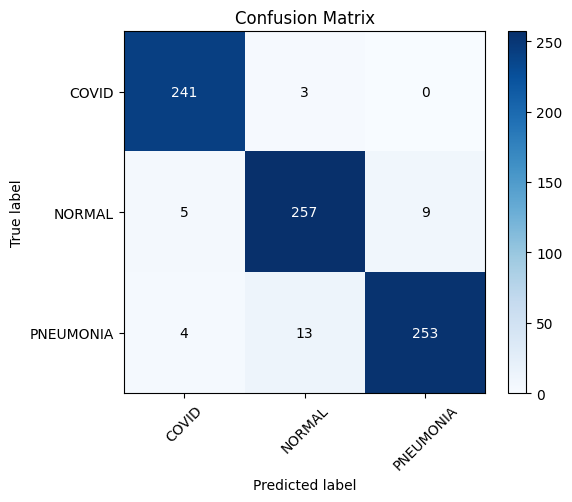

TEST acc         : 0.956687898089172
TEST macro_f1    : 0.957229754249878
TEST weighted_f1 : 0.9566019526508868
TEST per_class   : [{'precision': 0.964, 'recall': 0.9877049180327869, 'f1': 0.9757085020242914, 'support': 244}, {'precision': 0.9413919413919414, 'recall': 0.948339483394834, 'f1': 0.9448529411764706, 'support': 271}, {'precision': 0.9656488549618321, 'recall': 0.937037037037037, 'f1': 0.9511278195488722, 'support': 270}]


{'acc': 0.956687898089172,
 'micro_precision': 0.956687898089172,
 'micro_recall': 0.956687898089172,
 'micro_f1': 0.956687898089172,
 'macro_precision': 0.9570135987845911,
 'macro_recall': 0.9576938128215526,
 'macro_f1': 0.957229754249878,
 'weighted_precision': 0.9567623018559372,
 'weighted_recall': 0.956687898089172,
 'weighted_f1': 0.9566019526508868,
 'per_class': [{'precision': 0.964,
   'recall': 0.9877049180327869,
   'f1': 0.9757085020242914,
   'support': 244},
  {'precision': 0.9413919413919414,
   'recall': 0.948339483394834,
   'f1': 0.9448529411764706,
   'support': 271},
  {'precision': 0.9656488549618321,
   'recall': 0.937037037037037,
   'f1': 0.9511278195488722,
   'support': 270}],
 'confusion_matrix': tensor([[241,   3,   0],
         [  5, 257,   9],
         [  4,  13, 253]]),
 'logits': tensor([[-1.7415, -0.6471,  2.2974],
         [-1.3972,  0.6035,  0.5596],
         [-1.3148,  2.5020, -1.5586],
         ...,
         [ 2.8791, -1.6122, -1.2521],
         [

In [ ]:
# load best model
ckpt = torch.load("checkpoints/resnet50_best.pt", map_location=device)

if isinstance(ckpt, dict) and "model_state" in ckpt:
    model_resnet_enc.load_state_dict(ckpt["model_state"])
else:
    model_resnet_enc.load_state_dict(ckpt)

model_resnet_enc.to(device)
model_resnet_enc.eval()

# evaluate on TEST
test_result = evaluate_full(
    model_resnet_enc,
    test_enc_loader,
    device=device,
    num_classes=3
)

plot_confusion_matrix(
    test_result["confusion_matrix"],
    class_names=train_enc_ds_full.classes,
    normalize=False
)

print("TEST acc         :", test_result["acc"])
print("TEST macro_f1    :", test_result["macro_f1"])
print("TEST weighted_f1 :", test_result["weighted_f1"])
print("TEST per_class   :", test_result["per_class"])

test_result

## k = 8

In [ ]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import Subset
from sklearn.model_selection import train_test_split
import numpy as np

ENC_ROOT = "/content/new_dataset_encrypted/k_8"

BATCH_SIZE = 128
NUM_WORKERS = 12
SEED = 42


# Load toàn bộ dataset, không cần folder train/test
full_ds = ImageFolder(ENC_ROOT)

targets = np.array(full_ds.targets)
indices = np.arange(len(full_ds))


# Split train / temp
train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.3,
    stratify=targets,
    random_state=SEED
)

# Split temp thành val / test
temp_targets = targets[temp_idx]

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    stratify=temp_targets,
    random_state=SEED
)


print("Train:", len(train_idx))
print("Val:", len(val_idx))
print("Test:", len(test_idx))


# Transform chỉ để tính mean/std
tf_stats = transforms.Compose([
    transforms.ToTensor(),
])

stats_ds_full = ImageFolder(
    ENC_ROOT,
    transform=tf_stats
)

train_stats_ds = Subset(stats_ds_full, train_idx)


mean_enc, std_enc = compute_mean_std(
    train_stats_ds,
    batch_size=BATCH_SIZE,
    max_samples=None
)

print("mean_enc:", mean_enc)
print("std_enc :", std_enc)

Train: 3659
Val: 784
Test: 785


Compute mean/std:   0%|          | 0/29 [00:00<?, ?it/s]

mean_enc: [0.11062648892402649, 0.1106894463300705, 0.11101848632097244]
std_enc : [0.20405369997024536, 0.20394322276115417, 0.2043202668428421]


In [ ]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
import numpy as np

# ENC_ROOT = "/content/data_encrypted"
# train_idx, val_idx, test_idx đã có từ bước split
# mean_enc, std_enc đã tính từ train_stats_ds


# =========================
# 3) Transform
# =========================
print(ENC_ROOT)

BATCH_SIZE = 16
train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(3),
    transforms.ToTensor(),
    transforms.Normalize(mean_enc, std_enc),
])

eval_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean_enc, std_enc),
])


train_enc_ds_full = ImageFolder(ENC_ROOT, transform=train_tf)
eval_enc_ds_full  = ImageFolder(ENC_ROOT, transform=eval_tf)

train_enc_ds = Subset(train_enc_ds_full, train_idx)
val_enc_ds   = Subset(eval_enc_ds_full, val_idx)
test_enc_ds  = Subset(eval_enc_ds_full, test_idx)


train_enc_loader = DataLoader(
    train_enc_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=True
)

val_enc_loader = DataLoader(
    val_enc_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=False
)

test_enc_loader = DataLoader(
    test_enc_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=False
)


print("train:", len(train_enc_ds))
print("val  :", len(val_enc_ds))
print("test :", len(test_enc_ds))

print("classes:", train_enc_ds_full.classes)
print("class_to_idx:", train_enc_ds_full.class_to_idx)


# kiểm tra phân bố class từng split
targets = np.array(train_enc_ds_full.targets)

train_targets = targets[train_idx]
val_targets   = targets[val_idx]
test_targets  = targets[test_idx]

print("train class counts:", np.bincount(train_targets))
print("val   class counts:", np.bincount(val_targets))
print("test  class counts:", np.bincount(test_targets))

/content/new_dataset_encrypted/k_8
train: 3659
val  : 784
test : 785
classes: ['COVID', 'NORMAL', 'PNEUMONIA']
class_to_idx: {'COVID': 0, 'NORMAL': 1, 'PNEUMONIA': 2}
train class counts: [1138 1261 1260]
val   class counts: [244 270 270]
test  class counts: [244 271 270]


In [ ]:
import math
device = "cuda" if torch.cuda.is_available() else "cpu"

EPOCHS = 50
LR = 3e-4
model_resnet_enc = resnet50(
    num_classes=3,
    pretrained=True,
    freeze_backbone=False
).to(device)


best_path, csv_path = fit(
    model_resnet_enc,
    train_loader=train_enc_loader,
    val_loader=val_enc_loader,
    mixup = False,
    device=device,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=1e-4,
    patience=10,
    csv_path="logs/resnet50_log.csv",
    best_path="checkpoints/resnet50_best_k8.pt",
    num_classes=3,
    use_amp=True,
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Train:   0%|          | 0/228 [00:00<?, ?it/s]

Epoch 01/50 | train loss 0.5725 acc 0.8185 || val loss 0.5221 acc 0.8253 macroF1 0.8230 | lr 3.00e-04 save


Train:   0%|          | 0/228 [00:00<?, ?it/s]

Epoch 02/50 | train loss 0.4167 acc 0.8931 || val loss 0.3477 acc 0.9209 macroF1 0.9207 | lr 2.99e-04 save


...

Epoch 27/50 | train loss 0.1730 acc 0.9989 || val loss 0.2654 acc 0.9617 macroF1 0.9626 | lr 1.31e-04


Train:   0%|          | 0/228 [00:00<?, ?it/s]

Epoch 28/50 | train loss 0.1725 acc 0.9992 || val loss 0.2588 acc 0.9668 macroF1 0.9675 | lr 1.22e-04


Train:   0%|          | 0/228 [00:00<?, ?it/s]

Epoch 29/50 | train loss 0.1722 acc 0.9995 || val loss 0.2704 acc 0.9605 macroF1 0.9612 | lr 1.13e-04
Early stopping at epoch 29 (best macroF1=0.9724)


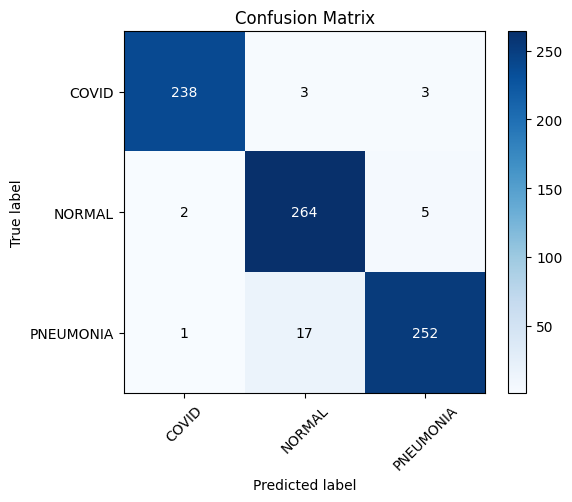

TEST acc         : 0.9605095541401274
TEST macro_f1    : 0.9612460155156128
TEST weighted_f1 : 0.9605644562366903
TEST per_class   : [{'precision': 0.9875518672199171, 'recall': 0.9754098360655737, 'f1': 0.9814432989690722, 'support': 244}, {'precision': 0.9295774647887324, 'recall': 0.974169741697417, 'f1': 0.9513513513513514, 'support': 271}, {'precision': 0.9692307692307692, 'recall': 0.9333333333333333, 'f1': 0.9509433962264151, 'support': 270}]


{'acc': 0.9605095541401274,
 'micro_precision': 0.9605095541401274,
 'micro_recall': 0.9605095541401274,
 'micro_f1': 0.9605095541401274,
 'macro_precision': 0.9621200337464728,
 'macro_recall': 0.9609709703654413,
 'macro_f1': 0.9612460155156128,
 'weighted_precision': 0.9612362500021834,
 'weighted_recall': 0.9605095541401274,
 'weighted_f1': 0.9605644562366903,
 'per_class': [{'precision': 0.9875518672199171,
   'recall': 0.9754098360655737,
   'f1': 0.9814432989690722,
   'support': 244},
  {'precision': 0.9295774647887324,
   'recall': 0.974169741697417,
   'f1': 0.9513513513513514,
   'support': 271},
  {'precision': 0.9692307692307692,
   'recall': 0.9333333333333333,
   'f1': 0.9509433962264151,
   'support': 270}],
 'confusion_matrix': tensor([[238,   3,   3],
         [  2, 264,   5],
         [  1,  17, 252]]),
 'logits': tensor([[-1.8085, -0.8648,  2.2305],
         [-1.4511,  2.4210, -1.7935],
         [-1.5313,  2.2435, -1.7001],
         ...,
         [ 2.4317, -1.7520, 

In [ ]:
# load best model
ckpt = torch.load("checkpoints/resnet50_best_k8.pt", map_location=device)

if isinstance(ckpt, dict) and "model_state" in ckpt:
    model_resnet_enc.load_state_dict(ckpt["model_state"])
else:
    model_resnet_enc.load_state_dict(ckpt)

model_resnet_enc.to(device)
model_resnet_enc.eval()

# evaluate on TEST
test_result = evaluate_full(
    model_resnet_enc,
    test_enc_loader,
    device=device,
    num_classes=3
)

plot_confusion_matrix(
    test_result["confusion_matrix"],
    class_names=train_enc_ds_full.classes,
    normalize=False
)

print("TEST acc         :", test_result["acc"])
print("TEST macro_f1    :", test_result["macro_f1"])
print("TEST weighted_f1 :", test_result["weighted_f1"])
print("TEST per_class   :", test_result["per_class"])

test_result